Import some useful libraries

In [24]:
from LQR import *
from DGM import *
from FNN import *
from PDE_Solve_dgm import *
from Policy_Iteration import *

Define LQR parameters

In [2]:
H = np.array([[1.0, 0.5], [0.0, 1.0]])
M = np.array([[1.0, 0.0], [0.0, 1.0]])
C = np.array([[1.0, 0.0], [0.0, 1.0]])
D = np.array([[1.0, 0.0], [0.0, 1.0]])
R = np.array([[1.0, 0.0], [0.0, 1.0]])
sigma = np.array([[0.5, 0.0], [0.0, 0.5]])
T = 1.0

lqr = LQR(H, M, C, D, R, sigma, T)

Exercise 1.1 : Solve Riccati ODE and test value function and control

In [3]:
time_grid = np.linspace(0, T, 500)
lqr.Sol_Ricatti(time_grid)

t_test = torch.tensor([0.0, 0.5, 1.0], dtype=torch.float32)
x_test = torch.tensor([[[1.0, 1.0]],[[0.0, 1.0]],[[1.0, 2.0]]],dtype=torch.float32)

v = lqr.Sol_value(t_test, x_test)
a = lqr.control(t_test, x_test)

print("\n Value function v(t, x):")
for i in range(len(t_test)):
    print(f"t={t_test[i].item():.1f}, x={x_test[i,0,:].tolist()} -> v={v[i].item():.4f}")

print("\n Optimal control a(t, x):")
for i in range(len(t_test)):
    a_i = a[i].tolist()
    a_str = f"[{a_i[0]:.4f}, {a_i[1]:.4f}]"
    print(f"t={t_test[i].item():.1f}, x={x_test[i,0,:].tolist()} -> a={a_str}")


 Value function v(t, x):
t=0.0, x=[1.0, 1.0] -> v=6.2425
t=0.5, x=[0.0, 1.0] -> v=2.2742
t=1.0, x=[1.0, 2.0] -> v=5.0000

 Optimal control a(t, x):
t=0.0, x=[1.0, 1.0] -> a=[-2.6109, -2.7355]
t=0.5, x=[0.0, 1.0] -> a=[-0.2771, -1.9066]
t=1.0, x=[1.0, 2.0] -> a=[-1.0000, -2.0000]


Exercise 1.2: Monte Carlo Error Analysis

Benchmark value v(t,x) = 6.242467
N_steps=    1, mean abs error=1.1112e+01
N_steps=   10, mean abs error=3.8545e-01
N_steps=   50, mean abs error=6.8353e-02
N_steps=  100, mean abs error=3.8027e-02
N_steps=  500, mean abs error=9.9926e-03
N_steps= 1000, mean abs error=4.9026e-03
N_steps= 5000, mean abs error=4.6464e-03
N_samples=    10, mean abs error=2.9838e-01
N_samples=    50, mean abs error=2.8148e-01
N_samples=   100, mean abs error=9.0514e-02
N_samples=   500, mean abs error=1.0339e-01
N_samples=  1000, mean abs error=5.3842e-02
N_samples=  5000, mean abs error=1.7643e-02
N_samples= 10000, mean abs error=2.2031e-02
N_samples= 50000, mean abs error=7.5012e-03
N_samples=100000, mean abs error=6.8227e-03


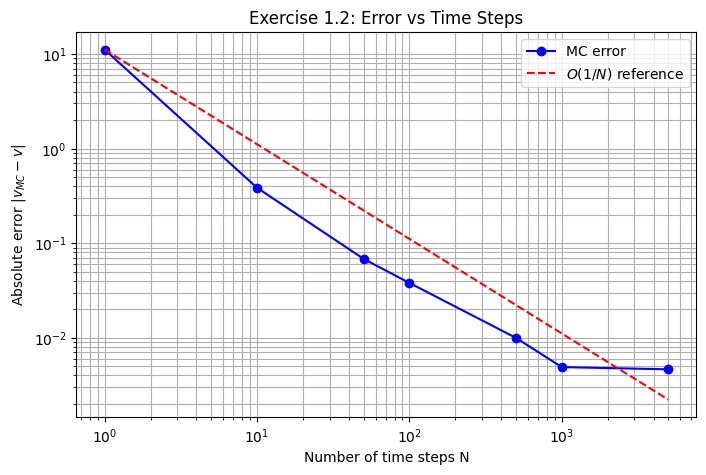

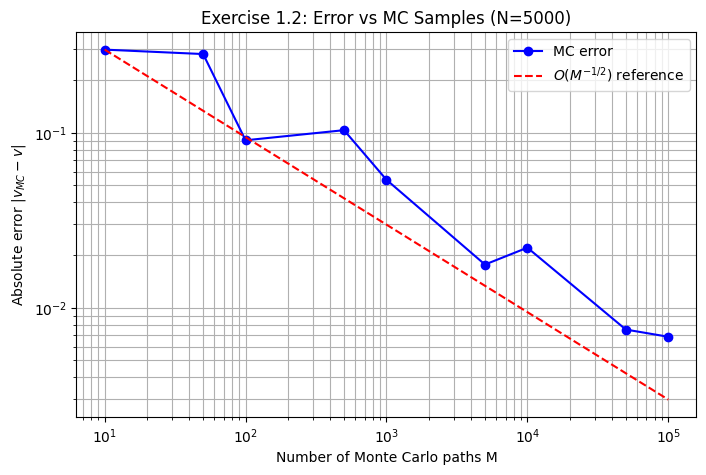

{'v_exact': 6.242466926574707,
 'steps_list': [1, 10, 50, 100, 500, 1000, 5000],
 'errors_steps': [11.11176243752303,
  0.3854542582432172,
  0.06835346777774749,
  0.03802710374308109,
  0.009992557869522401,
  0.0049026139839652315,
  0.004646367264106566],
 'samples_list': [10, 50, 100, 500, 1000, 5000, 10000, 50000, 100000],
 'errors_samples': [0.2983848027651378,
  0.2814833370075256,
  0.09051417922179787,
  0.10339132745808648,
  0.05384177483293513,
  0.017642640183801284,
  0.022031346281191057,
  0.0075012029331393395,
  0.0068226708014577754]}

In [6]:
lqr.error_analysis(
    t=0.0,
    x=np.array([1.0, 1.0]),
    steps_list=[1, 10, 50, 100, 500, 1000, 5000],
    samples_list=[10, 50, 100, 500, 1000, 5000, 10000, 50000, 100000],
    fixed_paths=100000,
    fixed_steps=5000,
    repetitions=5,
    seed=1234)

Exercise 2.1: Supervised learning of value function

Epoch 0/1000, loss=193.009949
Epoch 100/1000, loss=1.937271
Epoch 200/1000, loss=0.512256
Epoch 300/1000, loss=0.155626
Epoch 400/1000, loss=0.068155
Epoch 500/1000, loss=0.041537
Epoch 600/1000, loss=0.025643
Epoch 700/1000, loss=0.018630
Epoch 800/1000, loss=0.020965
Epoch 900/1000, loss=0.010521


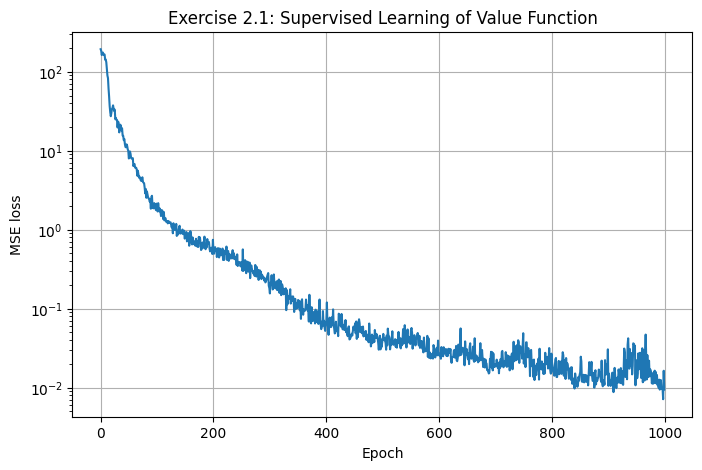

In [7]:
value_net, _ = train_value_network(lqr, n_epochs=1000, batch_size=1024, lr=1e-3)

Exercise 2.2: Supervised learning of control

Epoch 0/1000, Loss=9.995940
Epoch 500/1000, Loss=0.015576


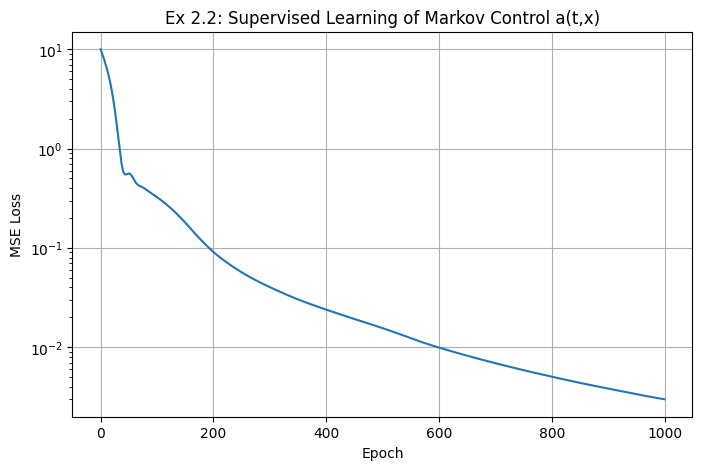

In [8]:
control_net, _ = train_control_network(lqr, n_epochs=1000, batch_size=1024, lr=1e-3)

Exercise 3.1: DGM for the linear PDE

The Monte Carlo benchmark below reuses the Exercise 1.2 simulation routine with constant control alpha=(1,1)^T.

Epoch 0/1000 | total=135.522110 | pde=83.441856 | boundary=52.080257
  -> mean MC benchmark error = 3.7356e+01
Epoch 100/1000 | total=4.104149 | pde=1.909223 | boundary=2.194926
Epoch 200/1000 | total=0.836662 | pde=0.407519 | boundary=0.429143
  -> mean MC benchmark error = 1.9709e+01
Epoch 300/1000 | total=0.125358 | pde=0.068031 | boundary=0.057327
Epoch 400/1000 | total=0.200078 | pde=0.127582 | boundary=0.072496
Epoch 500/1000 | total=0.062774 | pde=0.032027 | boundary=0.030747
  -> mean MC benchmark error = 1.7982e+01
Epoch 600/1000 | total=0.047831 | pde=0.019758 | boundary=0.028074
Epoch 700/1000 | total=0.240483 | pde=0.116134 | boundary=0.124349
  -> mean MC benchmark error = 1.8256e+01
Epoch 800/1000 | total=0.071192 | pde=0.036561 | boundary=0.034631
Epoch 900/1000 | total=0.026809 | pde=0.016396 | boundary=0.010413


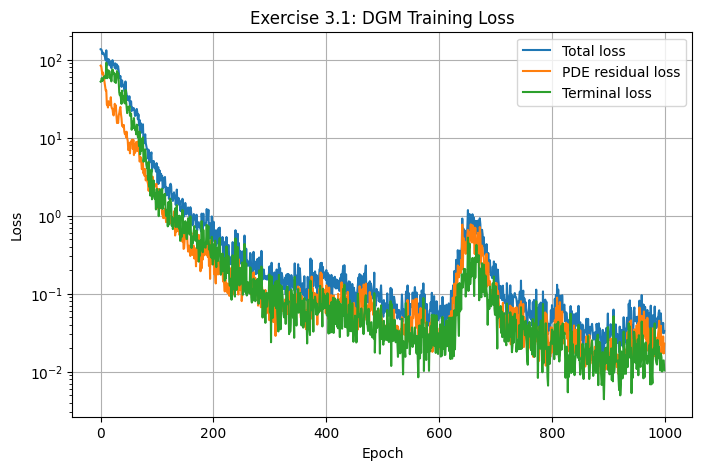

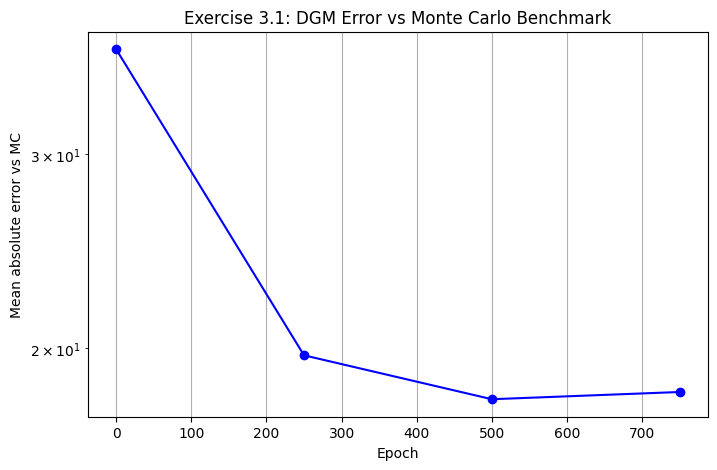

(Net_DGM(
   (input_layer): Sequential(
     (0): Linear(in_features=3, out_features=100, bias=True)
     (1): Tanh()
   )
   (DGM1): DGM_Layer(
     (activation): Tanh()
     (gate_Z): Sequential(
       (0): Linear(in_features=103, out_features=100, bias=True)
       (1): Tanh()
     )
     (gate_G): Sequential(
       (0): Linear(in_features=103, out_features=100, bias=True)
       (1): Tanh()
     )
     (gate_R): Sequential(
       (0): Linear(in_features=103, out_features=100, bias=True)
       (1): Tanh()
     )
     (gate_H): Sequential(
       (0): Linear(in_features=103, out_features=100, bias=True)
       (1): Tanh()
     )
   )
   (DGM2): DGM_Layer(
     (activation): Tanh()
     (gate_Z): Sequential(
       (0): Linear(in_features=103, out_features=100, bias=True)
       (1): Tanh()
     )
     (gate_G): Sequential(
       (0): Linear(in_features=103, out_features=100, bias=True)
       (1): Tanh()
     )
     (gate_R): Sequential(
       (0): Linear(in_features=103, out_f

In [9]:
train_dgm_linear_pde(lqr, n_epochs=1000, batch_size=128, lr=1e-3, eval_every=250)

Exercise 4.1: Policy iteration

In [41]:
train_policy_iteration(
        lqr,
        n_iterations=5,
        n_epochs_val=300,
        n_epochs_act=200,
        batch_size=128,
        lr=1e-3,
        initial_value_net=value_net,
        initial_control_net=control_net,
)

TypeError: train_policy_iteration() got an unexpected keyword argument 'initial_value_net'